In [19]:
import json
import spacy
import matplotlib.pyplot as plt

In [74]:
import json

# Load the first JSON file (original)
with open('./ssl_meanings.json', 'r') as file:
    original_data = json.load(file)

# Normalize values: lowercase and replace underscores with spaces
original_words = set(value.lower().replace('_', ' ') for value in original_data.values())

# Load the second JSON file
with open('./class_counts.json', 'r') as file:
    second_data = json.load(file)

# Normalize keys: lowercase and replace underscores with spaces
second_words = set(key.lower().replace('_', ' ') for key in second_data.keys())

# Find common words between the two sets
common_words = original_words.intersection(second_words)

# Print the common words
print("Common words:", common_words)

Common words: {'mother', 'house', 'school', 'today', 'you', 'hello', 'sister', 'tuesday', 'tomorrow', 'university', 'thank you', 'it', 'good'}


How It Works:
.lower(): Converts "You" to "you" and "Thank You" to "thank you".
.replace('_', ' '): Converts "Thank_you" to "Thank you".
After normalization, "thank you" from both files will match.
Example Output:
If your files contain:

ssl_meanings.json: "w047": "Thank You", "w002": "You"
class_counts.json: "Thank_you": 21, "you": 21 The output will include {'thank you', 'you'} because the normalization aligns the strings.
Limitations:
This still relies on exact string matching after normalization.
Synonyms like "big" and "large" or "good" and "great" won’t match because they’re different words, even though they have similar meanings.

In [75]:
# Load spaCy model
try:
    nlp = spacy.load('en_core_web_lg')
except OSError:
    print("Installing 'en_core_web_lg'...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_md"])
    nlp = spacy.load('en_core_web_md')

# Load JSON files
with open('./ssl_meanings.json', 'r') as file:
    original_data = json.load(file)
with open('./class_counts.json', 'r') as file:
    second_data = json.load(file)

# Find matches
common_words_with_counts = {}
similarity_threshold = 0.80  # Only accept very similar non-exact matches

for orig_value in original_data.values():
    normalized_orig = orig_value.lower().replace('_', ' ')
    matches = []
    # Check exact matches first
    for sec_key in second_data.keys():
        normalized_sec = sec_key.lower().replace('_', ' ')
        if normalized_orig == normalized_sec:
            matches = [(sec_key, second_data[sec_key], 1.0)]
            break  # Stop after exact match
    else:
        # No exact match, use semantic similarity
        orig_nlp = nlp(normalized_orig)
        for sec_key in second_data.keys():
            normalized_sec = sec_key.lower().replace('_', ' ')
            sec_nlp = nlp(normalized_sec)
            similarity = orig_nlp.similarity(sec_nlp)
            if similarity >= similarity_threshold:
                matches.append((sec_key, second_data[sec_key], similarity))
    
    if matches:
        common_words_with_counts[orig_value] = matches

# Print results
print("Number of similar classes: ", len(common_words_with_counts))
print("Common words with matching words, instance counts, and similarity scores from class_counts.json:")
for orig_word, matches in common_words_with_counts.items():
    for matched_word, count, similarity in matches:
        print(f"ssl_meanings: '{orig_word}' | class_counts: '{matched_word}' | Count: {count} | Similarity: {similarity:.3f}")

Number of similar classes:  20
Common words with matching words, instance counts, and similarity scores from class_counts.json:
ssl_meanings: 'To_You' | class_counts: 'you' | Count: 21 | Similarity: 0.924
ssl_meanings: 'To_You' | class_counts: 'How_are_you' | Count: 21 | Similarity: 0.857
ssl_meanings: 'You' | class_counts: 'you' | Count: 21 | Similarity: 1.000
ssl_meanings: 'Mother' | class_counts: 'Mother' | Count: 20 | Similarity: 1.000
ssl_meanings: 'It' | class_counts: 'it' | Count: 21 | Similarity: 1.000
ssl_meanings: 'Sister' | class_counts: 'Sister' | Count: 20 | Similarity: 1.000
ssl_meanings: 'University' | class_counts: 'University' | Count: 21 | Similarity: 1.000
ssl_meanings: 'Big' | class_counts: 'big_large' | Count: 21 | Similarity: 0.909
ssl_meanings: 'Good' | class_counts: 'good' | Count: 21 | Similarity: 1.000
ssl_meanings: 'Little' | class_counts: 'small_little' | Count: 22 | Similarity: 0.919
ssl_meanings: 'Today' | class_counts: 'Today' | Count: 14 | Similarity: 1.

In [78]:
# Copy call matched_word into a seperate list

matched_words = [matched_word for orig_word, matches in common_words_with_counts.items() for matched_word, count, similarity in matches]
matched_words

['you',
 'How_are_you',
 'you',
 'Mother',
 'it',
 'Sister',
 'University',
 'big_large',
 'good',
 'small_little',
 'Today',
 'Tomorrow',
 'School',
 'Child',
 'Tuesday',
 'House',
 'Hello',
 'Thank_you',
 'How_are_you',
 'How_are_you',
 'How_are_you']

In [79]:
matched_ssl_words = [orig_word for orig_word in common_words_with_counts.keys()]
matched_ssl_words

['To_You',
 'You',
 'Mother',
 'It',
 'Sister',
 'University',
 'Big',
 'Good',
 'Little',
 'Today',
 'Tomorrow',
 'School',
 'Children',
 'Tuesday',
 'House',
 'Hello',
 'Thank_You',
 'How',
 'What',
 'How_many']

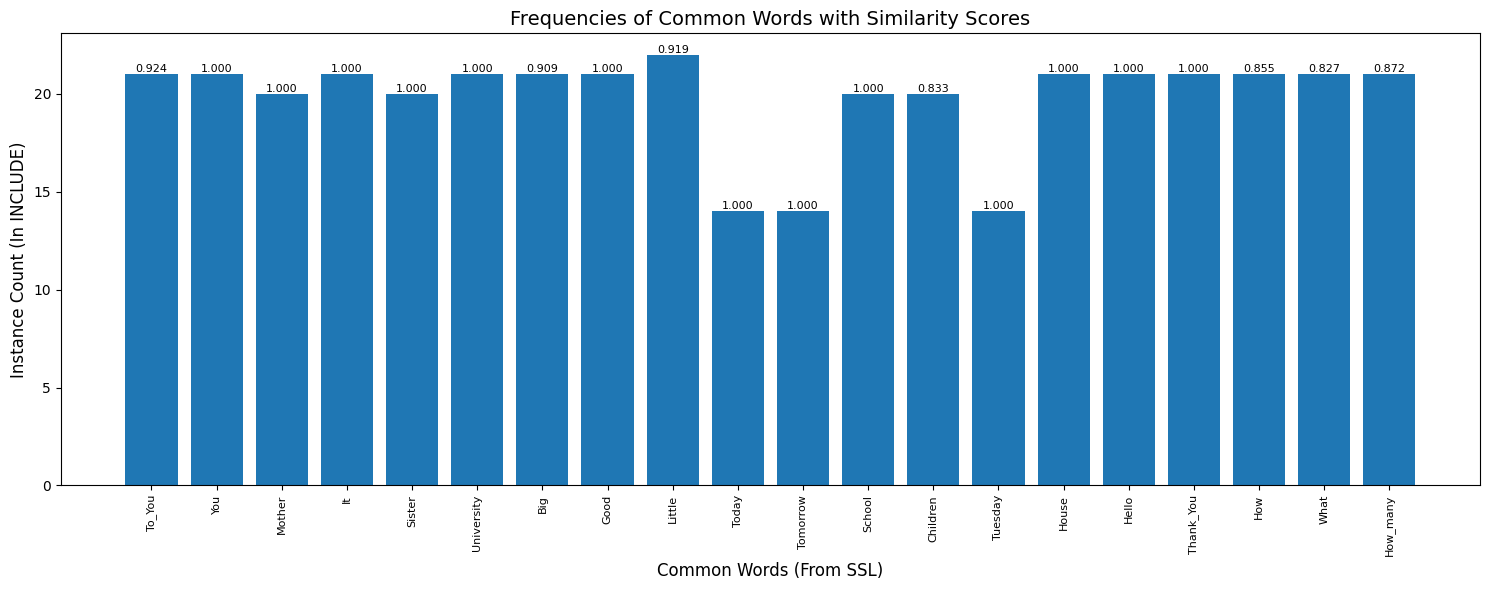

In [80]:
# Assuming common_words_with_counts is populated from your previous code
# Extract words, frequencies, and similarities (using first match)
words = []
frequencies = []
similarities = []
for orig_word, matches in common_words_with_counts.items():
    matched_word, count, similarity = matches[0]  # Use first match
    words.append(orig_word)
    frequencies.append(count)
    similarities.append(similarity)

# Create a wider figure
plt.figure(figsize=(15, 6))

# Plot bar chart
bars = plt.bar(range(len(words)), frequencies)

# Customize the plot
plt.title('Frequencies of Common Words with Similarity Scores', fontsize=14)
plt.xlabel('Common Words (From SSL)', fontsize=12)
plt.ylabel('Instance Count (In INCLUDE)', fontsize=12)
plt.xticks(range(len(words)), words, rotation=90, fontsize=8)

# Add similarity scores above each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{similarities[i]:.3f}',
             ha='center', va='bottom', fontsize=8, color='black')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

In [15]:
len(common_words_with_counts)

42

How It Works:
Normalization: Still applies lowercase and underscore-to-space conversion to handle basic formatting differences.
spaCy NLP: Converts each word/phrase into a vector representation based on its meaning.
Similarity Score: Compares vectors using cosine similarity (0 to 1). A threshold like 0.85 means words must be very similar in meaning to count as a match.
Examples:
"You" and "you" will match (similarity ~1.0).
"Thank You" and "Thank_you" will match (similarity ~1.0 after normalization).
"Big" and "big_large" might match (similarity > 0.85).
"Good" and "great" might match if the threshold is lowered (e.g., 0.7).
Example Output:
If your files contain:

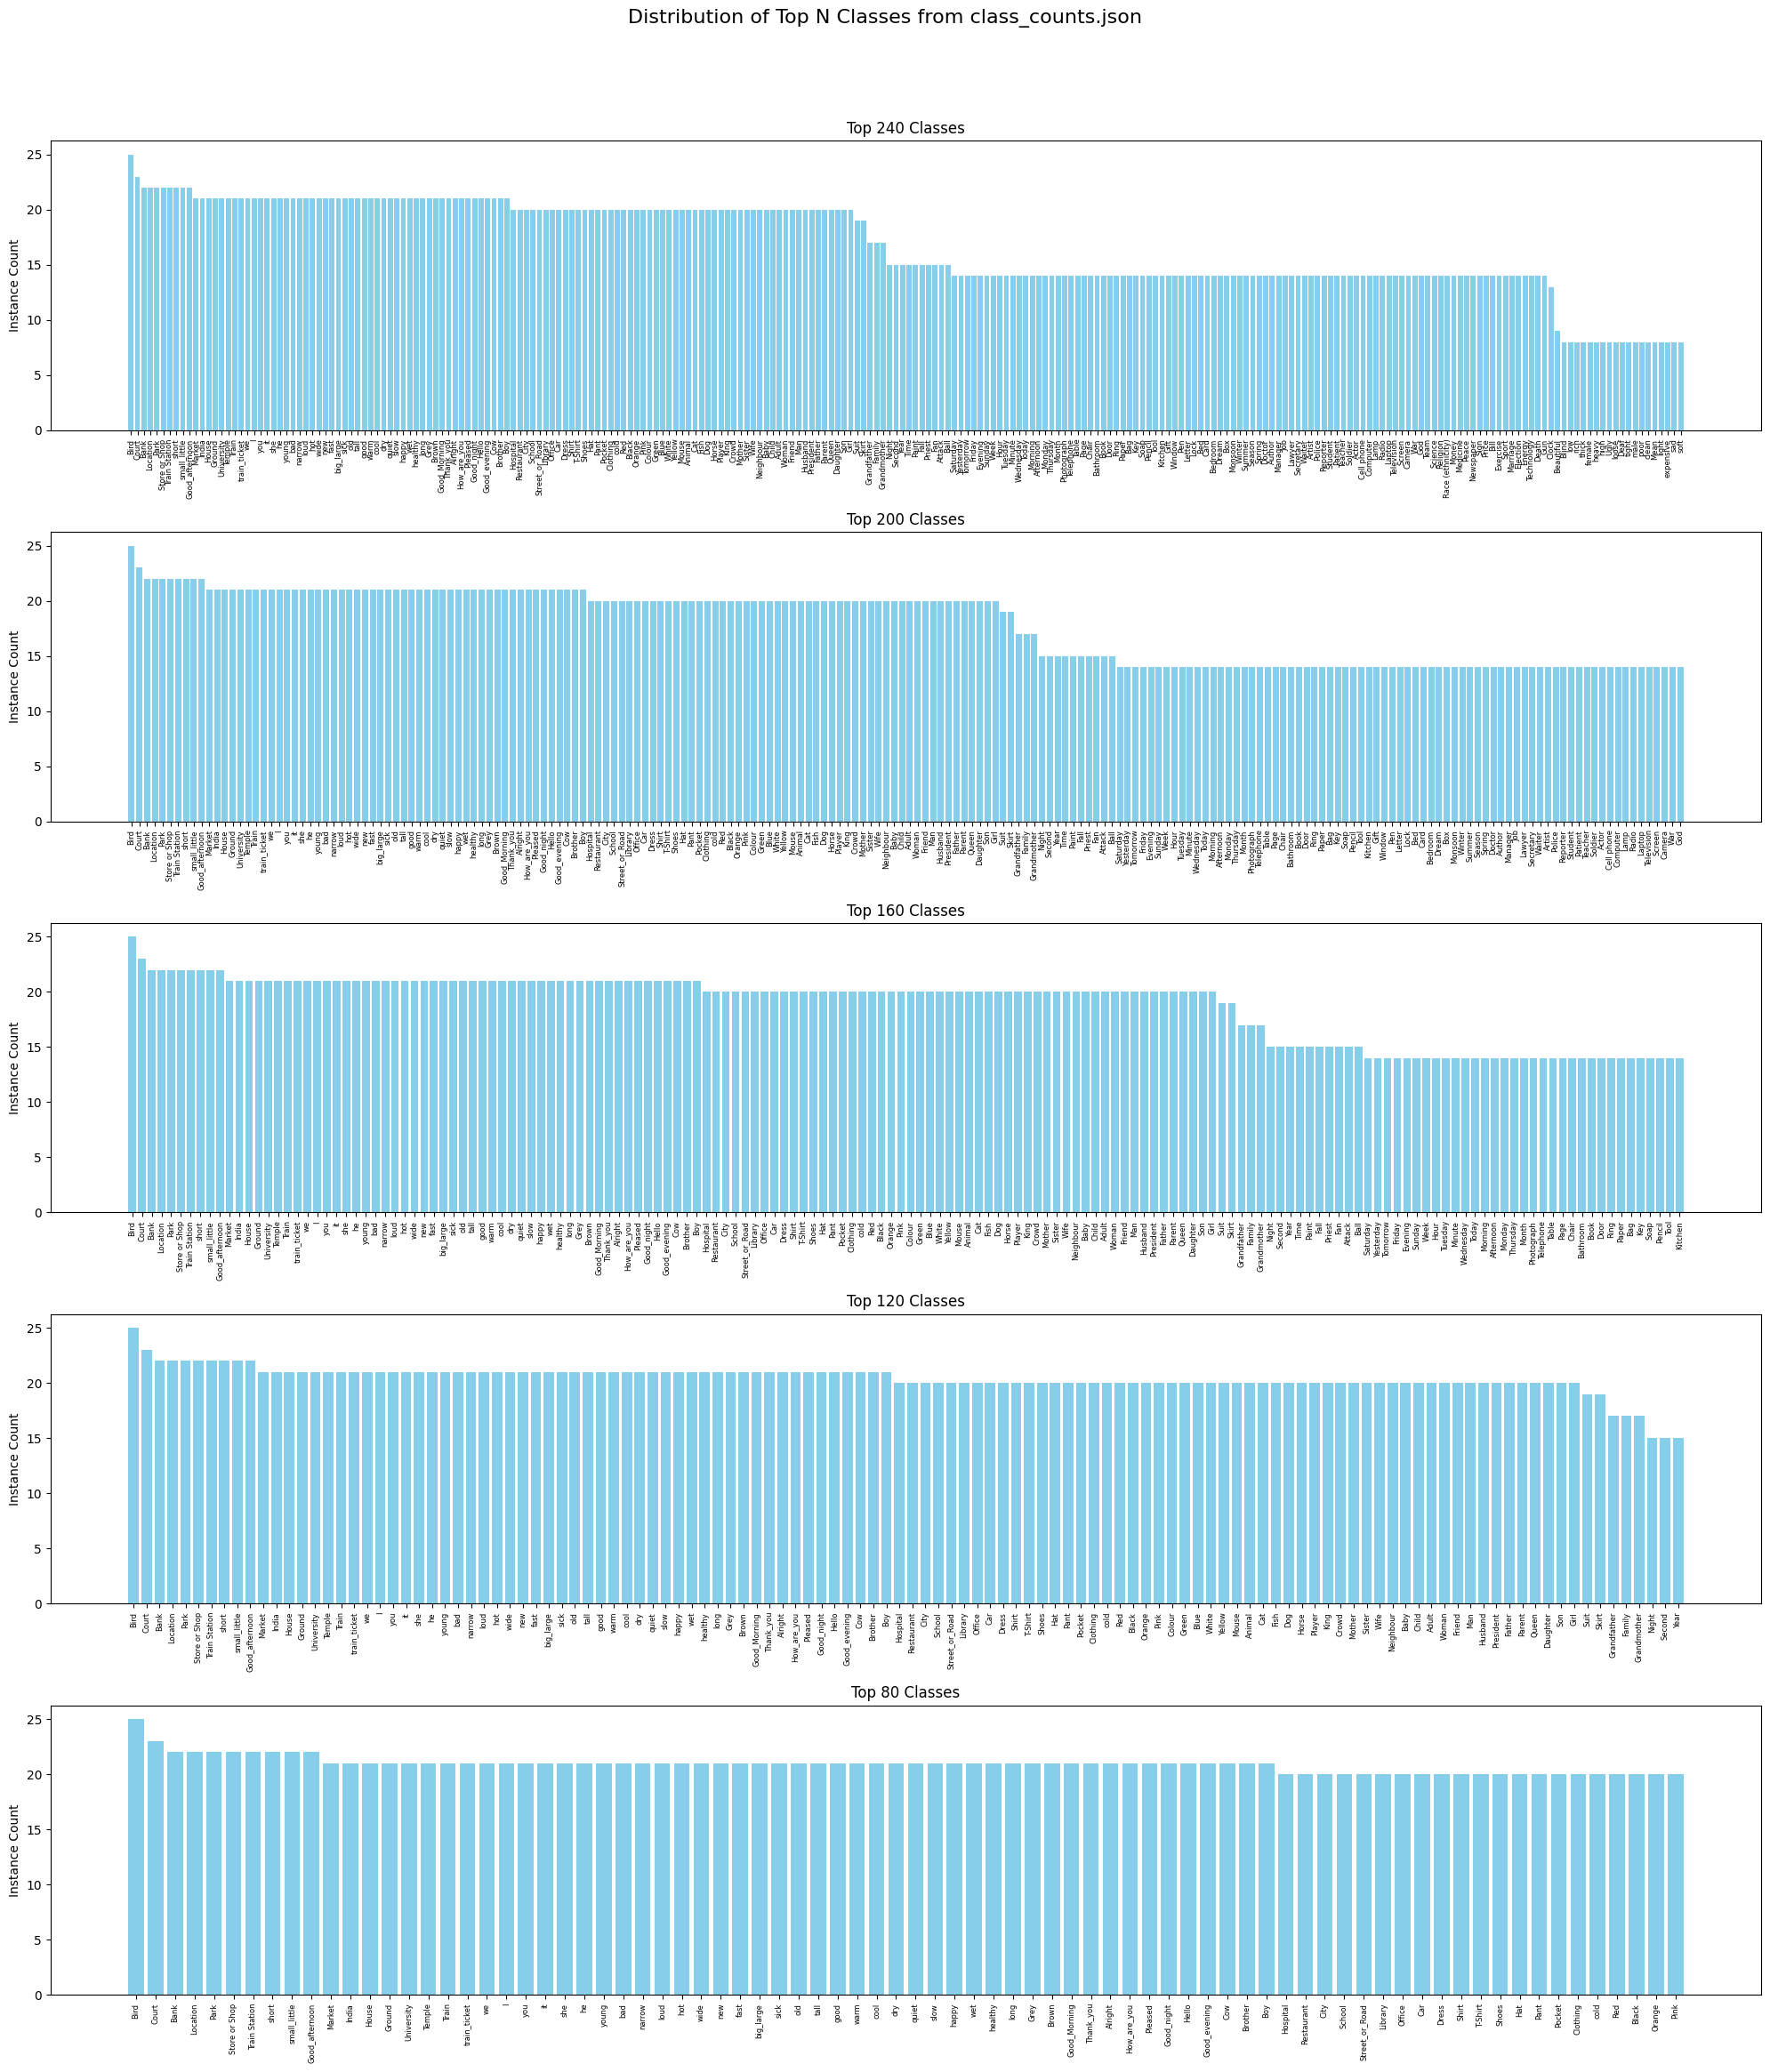

In [70]:
# Load the second JSON file (class_counts.json)
with open('./class_counts.json', 'r') as file:
    class_counts = json.load(file)

# Convert to a list of (class, count) tuples and sort by count in descending order
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

# Define the top N thresholds to plot
top_n_values = [240, 200, 160, 120, 80]

# Create subplots for each top N value with a wider figure
fig, axes = plt.subplots(len(top_n_values), 1, figsize=(20, 5 * len(top_n_values)), sharex=False)
fig.suptitle('Distribution of Top N Classes from class_counts.json', fontsize=16)

# If there's only one subplot, axes won't be a list, so handle it
if len(top_n_values) == 1:
    axes = [axes]

# Plot the distribution for each top N
for i, top_n in enumerate(top_n_values):
    # Get the top N classes
    top_classes = sorted_classes[:top_n]
    class_names = [item[0] for item in top_classes]
    counts = [item[1] for item in top_classes]

    # Plot a bar chart
    axes[i].bar(range(len(counts)), counts, color='skyblue')
    axes[i].set_title(f'Top {top_n} Classes', fontsize=12)
    axes[i].set_ylabel('Instance Count')

    # Set x-axis ticks and labels: small font, vertical orientation
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(class_names, rotation=90, fontsize=6)

# Adjust layout to prevent overlap (leaving space for rotated labels)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Show the plot
plt.show()